# Matrice transiliente de QdM (proxy sans traceur) + noyau d'entrainement causal

Notebook autonome regroupant les blocs **D1 (construction de b(z,z'))**, **D2 (rang / collapse / noyau parametrique)**
et **E (noyau causal d'entrainement pour Du et le flux de Reynolds)**, avec un **setup commun partage** en tete de
notebook pour ne plus avoir a re-deriver `rho0`, `alt`, `idx_stat`, `dx`, `dy`, etc. dans chaque cellule.

**Corrections apportees par rapport aux versions donnees en chat (elles plantaient) :**
- D1 : la detection de segments (runs verticaux de meme signe de `w`) comparait un tableau 2D (`S[k]`, forme `(ny,nx)`)
  a un scalaire dans un `if` -> `ValueError: truth value of an array is ambiguous`. Remplace par une segmentation
  **entierement vectorisee** (`np.add.at` / `np.minimum.at` / `np.maximum.at`), boucle uniquement sur `t` et `z`
  (quelques dizaines a centaines d'iterations), jamais sur `(y,x)`.
- D1 : chargement en memoire de `Uall`/`Wall` complets (`(nb, n_stat, ny, nx)`) -- plusieurs Go, risque de crash memoire.
  Remplace par un traitement **pas de temps par pas de temps**, avec `del` + `gc.collect()` a chaque iteration.
- D2 : le test de collapse dupliquait le code buggue de D1. Remplace par un **appel a la meme fonction corrigee**
  `build_transilient`, factorisee une fois pour toutes.
- E : referencait des variables non definies dans ce contexte (`Mc_humide`, `Du_humide`, `flux_zt`, `ubar_zt`) ->
  `NameError`. Le bloc est maintenant **entierement autonome** : il recalcule `M_c(z)`, `u_c(z)`, `u_e(z)`, `Du(z)`
  et le flux de Reynolds directement depuis `ua`/`wa`, sans dependre d'un notebook externe.

**Avant de lancer quoi que ce soit : execute la cellule SETUP ci-dessous, en collant ton bloc habituel
(chargement `rho0`, `alt`, `idx_stat`, `dx`, `dy`, `dt_phys`, `n_z`, `n_stat`, `n_x`, `n_y`, `path3d`, `path2d`,
`dim_t`, `dim_z`, `dim_y`, `dim_x`) a la place indiquee. La cellule de controle juste apres te dira immediatement,
et clairement, si quelque chose manque -- plutot qu'un plantage profond dans D1/D2/E.**


## 0. SETUP COMMUN -- a completer une seule fois

In [1]:
#============================================================
#  SETUP COMMUN — pipeline large300 (RCEMIP Meso-NH)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import xarray as xr
import gc, os
from scipy.signal import detrend, hilbert
from scipy.ndimage import uniform_filter1d

plt.rcParams.update({'figure.dpi':120,'font.size':11,'axes.grid':True,
                     'grid.alpha':0.25,'image.cmap':'RdBu_r'})
Rd,Rv=287.05,461.5; EPSILON=Rd/Rv; g=9.81; KARMAN=0.4
Z_TOP_KM=15.0
DIR_3D,DIR_2D,DIR_1D='3D','2D','1D'
def path3d(v): return os.path.join(DIR_3D,f'MESONH_RCE_large300_3D_{v}.nc')
def path2d(v): return os.path.join(DIR_2D,f'MESONH_RCE_large300_2D_{v}.nc')
def path1d(v): return os.path.join(DIR_1D,f'MESONH_RCE_large300_1D_{v}.nc')
BLOC=2

_ds=xr.open_dataset(path3d('ua')); _da=_ds['ua']
dim_t,dim_z,dim_y,dim_x=_da.dims[:4]
n_t,n_z=_da.sizes[dim_t],_da.sizes[dim_z]; n_y,n_x=_da.sizes[dim_y],_da.sizes[dim_x]
_xv=_da[dim_x].values; dx=float(np.mean(np.diff(_xv))) if _xv.size>1 else 1000.0
if abs(dx)<=1.5: dx=1000.0
_ds.close(); del _ds,_da; gc.collect()
_ds1=xr.open_dataset(path1d('ua_avg')); alt=_ds1.altitude.values.astype(float).copy(); _ds1.close()
x=np.arange(n_x,dtype=float)*dx; zkm=alt/1000.0
mask_show=alt<=Z_TOP_KM*1000; m28=(alt>=2000)&(alt<=8000)

# fenetre stationnaire = toute la fenetre (RCE quasi-stationnaire, cf. runs precedents)
t_stat=0; idx_stat=slice(t_stat,None); n_stat=n_t-t_stat
dt_phys=6*3600.0                      # RCEMIP : snapshots 3D 6-horaires

# masques humide/sec (PRW)
ds_prw=xr.open_dataset(path2d('prw')); prw_all=ds_prw['prw'].load(); ds_prw.close()
prw_mean=prw_all.isel({dim_t:idx_stat}).mean(dim=dim_t)
PRW_SEUIL=float(np.median(prw_all.values.ravel()))
mh=(prw_mean.values>PRW_SEUIL); ms=~mh; del prw_all; gc.collect()

print(f'{n_t} t x {n_z} z x {n_y} y x {n_x} x | dx={dx:.0f}m | dt={dt_phys/3600:.0f}h')
print(f'altitude {alt[0]:.0f}-{alt[-1]:.0f}m | z[1]={alt[1]:.0f}m | fenetre {n_stat} pas = {n_stat*dt_phys/86400:.0f} j')
print(f'humide {mh.mean()*100:.0f}% / sec {ms.mean()*100:.0f}% (seuil PRW={PRW_SEUIL:.1f})')


100 t x 74 z x 128 y x 2000 x | dx=1000m | dt=6h
altitude 0-32500m | z[1]=37m | fenetre 100 pas = 25 j
humide 43% / sec 57% (seuil PRW=30.4)


In [2]:
#============================================================
#  CHAMPS DE BASE : rho0(z), profils ET champs (z,t)
#   - profils moyens : flux_tot, ubar, dudz, uw       (1D, pour §1-§5-§6)
#   - champs (z,t)   : flux_zt, ubar_zt, wbar_zt, ...  (2D, pour le contexte)
# ============================================================
# rho0(z)
rho0_sum=np.zeros(n_z); n_rho=0
ds_ta=xr.open_dataset(path3d('ta')); ds_pa=xr.open_dataset(path3d('pa')); ds_hus=xr.open_dataset(path3d('hus'))
for t0 in range(t_stat,n_t,BLOC):
    t1=min(t0+BLOC,n_t); sl={dim_t:slice(t0,t1)}
    T=ds_ta['ta'].isel(sl).values; p=ds_pa['pa'].isel(sl).values; qv=ds_hus['hus'].isel(sl).values
    Tv=T*(1+qv/EPSILON)/(1+qv); rho=p/(Rd*Tv)
    rho0_sum+=rho.mean(axis=(0,2,3))*(t1-t0); n_rho+=(t1-t0)
    del T,p,qv,Tv,rho; gc.collect()
ds_ta.close(); ds_pa.close(); ds_hus.close(); rho0=rho0_sum/n_rho

# champs (z,t) : flux, ubar, wbar   (niveau par niveau)
flux_zt=np.zeros((n_z,n_stat)); ubar_zt=np.zeros((n_z,n_stat)); wbar_zt=np.zeros((n_z,n_stat))
ds_u=xr.open_dataset(path3d('ua')); ds_w=xr.open_dataset(path3d('wa'))
for iz in range(n_z):
    u=ds_u['ua'].isel({dim_t:idx_stat,dim_z:iz}).values
    w=ds_w['wa'].isel({dim_t:idx_stat,dim_z:iz}).values
    ub=u.mean(axis=(1,2)); wb=w.mean(axis=(1,2))
    up=u-ub[:,None,None]; wp=w-wb[:,None,None]
    flux_zt[iz]=rho0[iz]*(up*wp).mean(axis=(1,2)); ubar_zt[iz]=ub; wbar_zt[iz]=wb
    del u,w,up,wp; gc.collect()
ds_u.close(); ds_w.close(); gc.collect()

# profils moyens (moyenne temporelle des champs zt)
flux_tot=flux_zt.mean(1); ubar=ubar_zt.mean(1); wbar=wbar_zt.mean(1)
uw=flux_tot/rho0; dudz=np.gradient(ubar,alt); d2udz2=np.gradient(dudz,alt)
# derivees des champs zt (pour le contexte dynamique)
dudz_zt=np.gradient(ubar_zt,alt,axis=0); d2udz2_zt=np.gradient(dudz_zt,alt,axis=0)
uw_zt=flux_zt/rho0[:,None]
print(f'rho0 surface={rho0[0]:.3f} | ~10km={rho0[np.argmin(np.abs(alt-10000))]:.3f} kg/m3')
print('profils (flux_tot,ubar,dudz,uw) et champs (flux_zt,ubar_zt,...) prets.')


rho0 surface=1.183 | ~10km=0.410 kg/m3
profils (flux_tot,ubar,dudz,uw) et champs (flux_zt,ubar_zt,...) prets.


In [3]:
# --- Vérification des objets hérités du pipeline (setup notebook 8) ---
import numpy as np, matplotlib.pyplot as plt, gc
from numpy.linalg import lstsq

_required = ['rho0','alt','flux_zt','ubar_zt','wbar_zt','mh','ms',
             'dt_phys','n_stat','n_z','dim_t','dim_z','idx_stat']
_g = globals()
_missing = [k for k in _required if k not in _g]
assert not _missing, f"Objets manquants -> relance le setup large300 : {_missing}"

zkm   = alt/1000.0
Z_LO, Z_HI = 2000.0, 18000.0                 # fenêtre d'étude (2-18 km, comme la régression synthèse)
band  = (alt>=Z_LO)&(alt<=Z_HI)
iz_band = np.where(band)[0]

# profils moyens temporels (au cas où non définis)
flux_tot = flux_zt.mean(1)
ubar     = ubar_zt.mean(1)
dudz     = np.gradient(ubar, alt)
d2udz2   = np.gradient(dudz, alt)
uw       = flux_tot/rho0

print(f"OK. {n_z} niveaux, fenêtre 2-18 km = {band.sum()} niveaux, {n_stat} pas de temps.")
print(f"flux_tot min={flux_tot.min():.2e} @ {alt[np.argmin(flux_tot)]:.0f} m")


OK. 74 niveaux, fenêtre 2-18 km = 33 niveaux, 100 pas de temps.
flux_tot min=-1.17e-02 @ 4500 m


In [9]:
# ---- dy manquant : derive depuis la coordonnee dim_y de 'ua' -----------
_ds = xr.open_dataset(path3d('ua'))
_yv = _ds[dim_y].values.astype(float)
dy = float(np.mean(np.diff(_yv))) if _yv.size > 1 else dx
if abs(dy) <= 1.5:
    dy = dx      # coordonnee en km ou en indice -> on retombe sur dx (suppose grille reguliere)
_ds.close(); del _ds, _yv
gc.collect()

print(f"dy derive = {dy:.0f} m")

dy derive = 1000 m


In [15]:
zkm = alt / 1000.0

     

# ---- controle : verifie que le setup est complet AVANT d'aller plus loin ----
_required = ['path3d', 'path2d', 'dim_t', 'dim_z', 'dim_y', 'dim_x',
             'idx_stat', 'n_z', 'n_stat', 'n_x', 'n_y', 'rho0', 'alt', 'dx', 'dy', 'dt_phys']
_missing = [v for v in _required if v not in globals()]
if _missing:
    raise NameError(
        "Setup incomplet -- variables manquantes : " + ", ".join(_missing) +
        "\n=> colle ton bloc habituel dans la cellule SETUP ci-dessus, puis relance."
    )
print("Setup OK :")
print(f"  n_z={n_z}  n_stat={n_stat}  n_y={n_y}  n_x={n_x}")
print(f"  dx={dx:.0f} m   dy={dy:.0f} m   dt_phys={dt_phys/3600:.1f} h")
print(f"  alt : {alt.min():.0f} -> {alt.max():.0f} m   ({n_z} niveaux)")

     


Setup OK :
  n_z=74  n_stat=100  n_y=128  n_x=2000
  dx=1000 m   dy=1000 m   dt_phys=6.0 h
  alt : 0 -> 32500 m   (74 niveaux)


In [16]:
# ---- normalise idx_stat en tableau d'indices, quel que soit son type -----
if isinstance(idx_stat, slice):
    _ds_tmp = xr.open_dataset(path3d('ua'))
    _n_t_total = _ds_tmp.sizes[dim_t]
    _ds_tmp.close()
    idx_stat = np.arange(*idx_stat.indices(_n_t_total))
else:
    idx_stat = np.asarray(idx_stat)

n_stat = idx_stat.size   # recalcule pour rester coherent avec le idx_stat normalise

print(f"idx_stat normalise en tableau : {idx_stat.size} indices, de {idx_stat.min()} a {idx_stat.max()}")

idx_stat normalise en tableau : 100 indices, de 0 a 99


## 1. Fonction commune : segmentation verticale vectorisee

Un "eddy" est proxyfie par un **segment vertical contigu, dans une colonne (y,x) a un instant t donne, ou `w`
garde un signe constant et depasse un seuil**. L'origine/destination du segment (bas/haut selon le signe)
joue le role de `(z', z)` dans la definition de Romps & Kuang (eq. A1).

**Reserve a garder en tete** : ceci est un proxy eulerien, PAS la methode inject-and-decay du papier
(qui necessite des traceurs radioactifs actifs dans la simulation). Les controles de conservation
(D1, cellule suivante) ne tomberont donc pas au zero machine -- c'est attendu.

La fonction est vectorisee sur `(y,x)` (via `np.add.at` / `np.minimum.at` / `np.maximum.at`) et ne boucle
que sur `z` (quelques dizaines d'iterations) pour chaque pas de temps traite.


In [26]:
def build_transilient(S, W, rho_col, min_run=2):
    """
    Construit Btilde[dest, orig] = flux de masse (kg m^-2 s^-1, non normalise
    par surface/temps) transporte par des segments verticaux coherents.

    S : (nz, ny, nx) signe de w (deja seuille : +1/-1/0), UN SEUL pas de temps
    W : (nz, ny, nx) vitesse verticale, meme pas de temps
    rho_col : (nz,) densite de reference sur la meme grille reduite que S/W
    min_run : nb minimal de niveaux pour qu'un segment compte comme un "eddy"

    Retourne Btilde partiel (a accumuler sur tous les pas de temps par
    l'appelant), forme (nz, nz).
    """
    nz, ny, nx = S.shape
    nonzero = S != 0

    start = np.zeros_like(nonzero)
    start[0] = nonzero[0]
    start[1:] = nonzero[1:] & (S[1:] != S[:-1])

    seg_id = np.cumsum(start, axis=0) - 1
    seg_id = np.where(nonzero, seg_id, -1)

    flux_sum = np.zeros((nz, ny, nx))
    count    = np.zeros((nz, ny, nx), dtype=np.int32)
    zmin     = np.full((nz, ny, nx), nz, dtype=np.int32)
    zmax     = np.full((nz, ny, nx), -1, dtype=np.int32)
    sign_of  = np.zeros((nz, ny, nx))

    yy, xx = np.meshgrid(np.arange(ny), np.arange(nx), indexing='ij')

    for k in range(nz):
        valid = nonzero[k]
        if not valid.any():
            continue
        sid = seg_id[k][valid]
        y_v, x_v = yy[valid], xx[valid]
        val = np.abs(rho_col[k] * W[k][valid])
        np.add.at(flux_sum, (sid, y_v, x_v), val)
        np.add.at(count,    (sid, y_v, x_v), 1)
        np.minimum.at(zmin, (sid, y_v, x_v), k)
        np.maximum.at(zmax, (sid, y_v, x_v), k)
        sign_of[sid, y_v, x_v] = S[k][valid]

    ok = count >= min_run
    Btilde = np.zeros((nz, nz))
    if not ok.any():
        return Btilde

    s_idx  = sign_of[ok]
    zlo    = zmin[ok]
    zhi    = zmax[ok]
    meanfl = flux_sum[ok] / np.maximum(count[ok], 1)

    dest = np.where(s_idx > 0, zhi, zlo)
    orig = np.where(s_idx > 0, zlo, zhi)

    np.add.at(Btilde, (dest, orig), meanfl)
    return Btilde


def accumulate_transilient(ib, idx_time, W_SEUIL=0.3, MIN_RUN=2, verbose=True):
    """
    Boucle sur les pas de temps de idx_time (indices dans idx_stat, PAS
    dans le temps global), lit ua/wa niveau-complet par pas de temps
    (memoire bornee : un seul (nz,ny,nx) par variable a la fois),
    accumule Btilde sur toute la fenetre.

    ib : indices (dans la grille verticale complete) des niveaux retenus
    idx_time : indices (dans idx_stat) des pas de temps a utiliser
    """
    zb = alt[ib]; rb = rho0[ib]; nb = ib.size
    Btilde = np.zeros((nb, nb))
    ds_u = xr.open_dataset(path3d('ua'))
    ds_w = xr.open_dataset(path3d('wa'))
    t_global = idx_stat[idx_time]

    for n, it in enumerate(t_global):
        u = ds_u['ua'].isel({dim_t: it, dim_z: ib}).values.astype(np.float32)
        w = ds_w['wa'].isel({dim_t: it, dim_z: ib}).values.astype(np.float32)
        S = np.sign(w); S[np.abs(w) < W_SEUIL] = 0
        Btilde += build_transilient(S, w, rb, min_run=MIN_RUN)
        del u, w, S
        if n % 20 == 0:
            gc.collect()
            if verbose:
                print(f"  t={n}/{len(t_global)}")
    ds_u.close(); ds_w.close(); gc.collect()
    return Btilde, zb, rb, nb


## 2. D1 -- Construction de b(z,z') sur toute la fenetre stationnaire

Bande d'etude 2-18 km (comme dans le reste du stage). `W_SEUIL` et `MIN_RUN` sont les deux seuls parametres
libres -- regarde le message `[ctrl]` en sortie pour juger s'ils sont raisonnables avant d'interpreter quoi
que ce soit.


In [27]:
Z_LO, Z_HI = 2000.0, 18000.0
band = (alt >= Z_LO) & (alt <= Z_HI)
ib = np.where(band)[0]

W_SEUIL = 0.3     # m/s, seuil de coherence verticale (cf. reserve methodologique ci-dessus)
MIN_RUN = 2        # nb minimal de niveaux pour qu'un segment compte

Btilde, zb, rb, nb = accumulate_transilient(ib, np.arange(n_stat), W_SEUIL=W_SEUIL, MIN_RUN=MIN_RUN)

dz_b = np.gradient(zb)
norm = n_stat * n_y * n_x * np.outer(dz_b, dz_b)   # dx*dy en trop retire
Btilde_norm = Btilde / np.maximum(norm, 1e-30)

print(f"[ctrl] Btilde >= 0 hors diagonale : "
      f"{(Btilde_norm[~np.eye(nb, dtype=bool)] < -1e-12).sum()} valeurs negatives (attendu : 0, Btilde~ est une somme de |.|)")


  t=0/100
  t=20/100
  t=40/100
  t=60/100
  t=80/100
[ctrl] Btilde >= 0 hors diagonale : 0 valeurs negatives (attendu : 0, Btilde~ est une somme de |.|)


[ctrl] conservation colonne (source nette a z')  : 3.81e-11  (/ max|b| = 0.13%)
[ctrl] conservation ligne   (source nette a z)   : 1.84e-08  (/ max|b| = 64.56%)
(non-zero attendu : proxy eulerien + terme diffusif des petits eddies omis.
 Si le ratio depasse ~30-50%, resserrer W_SEUIL avant d'interpreter b_full.)


/tmp/ipykernel_19613/1186656720.py:27: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im = ax.pcolormesh(zb/1e3, zb/1e3, b_full, cmap='RdBu_r', vmin=-vmax, vmax=vmax, shading='auto')


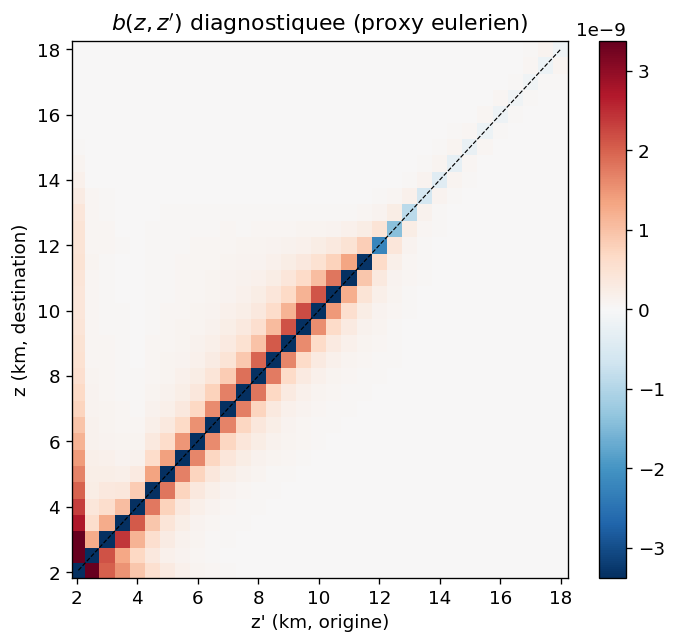

In [28]:
# --- M(z) : flux de masse compensatoire (subsidence), eq. (2) de Romps & Kuang ---
M = np.zeros(nb)
for i in range(nb):
    up = Btilde_norm[:i, i+1:].sum() if i + 1 < nb else 0.0
    down = Btilde_norm[i+1:, :i].sum() if i > 0 else 0.0
    M[i] = up - down

# --- assemblage de b(z,z') complet, eq. (3) (diffusion des petits eddies omise -> residu) ---
b_full = Btilde_norm.copy()
for i in range(nb):
    b_full[i, i] -= Btilde_norm[:, i].sum()      # depart d'eddies partant de z=i
dM = np.gradient(M, zb)
for i in range(nb):
    b_full[i, i] += dM[i]                         # subsidence compensatoire (approx diagonale)

# --- controles de conservation (eq. 5-6 de Romps & Kuang) ---
e_col = np.abs(b_full.sum(axis=0)).max()
e_row = np.abs(b_full.sum(axis=1)).max()
scale = np.abs(b_full).max()
print(f"[ctrl] conservation colonne (source nette a z')  : {e_col:.2e}  (/ max|b| = {e_col/scale:.2%})")
print(f"[ctrl] conservation ligne   (source nette a z)   : {e_row:.2e}  (/ max|b| = {e_row/scale:.2%})")
print("(non-zero attendu : proxy eulerien + terme diffusif des petits eddies omis.")
print(" Si le ratio depasse ~30-50%, resserrer W_SEUIL avant d'interpreter b_full.)")

fig, ax = plt.subplots(figsize=(6, 5.5))
vmax = np.percentile(np.abs(b_full), 98)
im = ax.pcolormesh(zb/1e3, zb/1e3, b_full, cmap='RdBu_r', vmin=-vmax, vmax=vmax, shading='auto')
ax.plot(zb/1e3, zb/1e3, 'k--', lw=.7)
ax.set_xlabel("z' (km, origine)"); ax.set_ylabel('z (km, destination)')
ax.set_title(r"$b(z,z^\prime)$ diagnostiquee (proxy eulerien)")
fig.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()


## 3. D2 -- De b(z,z') a une parametrisation grande echelle

Trois tests dans l'ordre : rang effectif (SVD), stabilite de la forme entre sous-fenetres temporelles
(test de collapse -- reutilise `accumulate_transilient`, plus de code duplique), puis ajustement d'un
noyau parametrique simple si la forme est stable.


In [29]:
# ---- A. rang effectif (SVD) --------------------------------------------
Uo, So, Vt = np.linalg.svd(b_full)
energie = np.cumsum(So**2) / np.sum(So**2)
r90 = int(np.searchsorted(energie, 0.90)) + 1
print(f"rang pour 90% de l'energie : {r90} / {nb}")
print(f"valeurs singulieres (normalisees) : {np.array2string(So[:8]/So[0], precision=3)}")


rang pour 90% de l'energie : 12 / 33
valeurs singulieres (normalisees) : [1.    0.348 0.332 0.328 0.317 0.305 0.302 0.3  ]


  fenetre 0: ||B||=2.334e+04
  fenetre 1: ||B||=2.287e+04
  fenetre 2: ||B||=2.351e+04
  fenetre 3: ||B||=2.324e+04

dispersion relative de la forme normalisee (zones significatives) : mediane 0.05
(<0.3 => collapse credible ; >1 => la forme change trop pour figer un noyau unique)


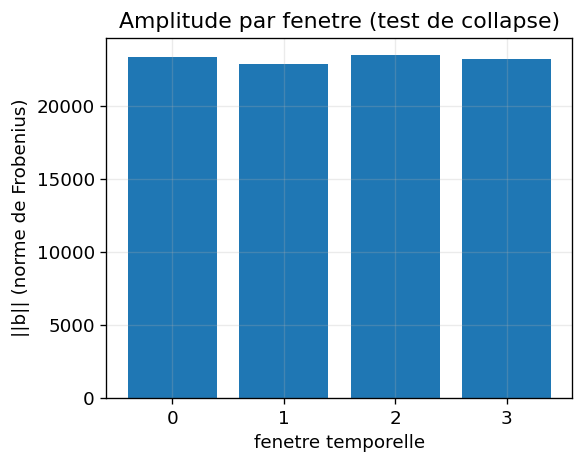

In [30]:
# ---- B. test de collapse : b(t) = A(t) * S(z,z') -------------------------
NWIN = 4
edges = np.linspace(0, n_stat, NWIN + 1).astype(int)
formes, amps = [], []
for w in range(NWIN):
    idx_win = np.arange(edges[w], edges[w + 1])
    Bw, _, _, _ = accumulate_transilient(ib, idx_win, W_SEUIL=W_SEUIL, MIN_RUN=MIN_RUN, verbose=False)
    A_w = np.linalg.norm(Bw)
    formes.append(Bw / (A_w + 1e-30))
    amps.append(A_w)
    print(f"  fenetre {w}: ||B||={A_w:.3e}")

formes = np.array(formes)
ref = np.abs(formes.mean(axis=0))
dispersion = formes.std(axis=0) / np.maximum(ref, ref.max() * 1e-6)
mask_signif = ref > np.percentile(ref, 75)   # ne juger la dispersion que la ou le signal est fort
print(f"\ndispersion relative de la forme normalisee (zones significatives) : "
      f"mediane {np.nanmedian(dispersion[mask_signif]):.2f}")
print("(<0.3 => collapse credible ; >1 => la forme change trop pour figer un noyau unique)")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(range(NWIN), amps)
ax.set_xlabel('fenetre temporelle'); ax.set_ylabel('||b|| (norme de Frobenius)')
ax.set_title("Amplitude par fenetre (test de collapse)")
plt.tight_layout(); plt.show()


In [31]:
# ---- C. ajustement parametrique du noyau hors-diagonale -----------------
# forme testee : b_offdiag(z,z\') ~ M0 * sign(z-z\') * exp(-|z-z\'|/L)
from scipy.optimize import curve_fit

off = b_full - np.diag(np.diag(b_full))
def modele(X, M0, L):
    zz, zzp = X
    return M0 * np.sign(zz - zzp) * np.exp(-np.abs(zz - zzp) / max(L, 1e-3))

ZZ, ZZP = np.meshgrid(zb, zb)
mask = ~np.eye(nb, dtype=bool)

kernel_ok = False
try:
    popt, _ = curve_fit(modele, (ZZ[mask], ZZP[mask]), off[mask],
                         p0=[np.abs(off).max(), 3000], maxfev=5000)
    M0, L = popt
    pred = modele((ZZ, ZZP), *popt)
    nse_fit = 1 - np.sum((off[mask] - pred[mask])**2) / np.sum((off[mask] - off[mask].mean())**2)
    print(f"noyau parametrique : M0={M0:.2e} kg/m^4/s, L={L:.0f} m, NSE={nse_fit:+.3f}")
    if nse_fit > 0.3:
        print("=> forme transportable : b(z,z\') = M0 * sign(z-z\') * exp(-|z-z\'|/L)")
        kernel_ok = True
    else:
        print("=> ajustement pauvre : la forme exponentielle simple ne capture pas b(z,z\')")
except RuntimeError:
    print("ajustement du noyau exponentiel a echoue -- la forme n'est pas simple")


noyau parametrique : M0=-5.22e-11 kg/m^4/s, L=-5691 m, NSE=-0.133
=> ajustement pauvre : la forme exponentielle simple ne capture pas b(z,z')


## 4. E -- Noyau causal d'entrainement pour Du et le flux de Reynolds

Bloc **entierement autonome** : `M_c(z)`, `u_c(z)`, `u_e(z)`, `Du(z)`, `eps(z)` et le flux de Reynolds sont
recalcules ici depuis `ua`/`wa`, sans dependre du notebook principal.

Rappel du modele : si un updraft conserve approximativement sa quantite de mouvement en montant, diluee par
entrainement, alors `Du(z) = u_c(z) - ubar(z)` obeit a

`Du(z) = - integrale_{z0}^{z} K(z,z') * dubar/dz'(z') dz'`,  `K(z,z') = exp( - integrale_{z'}^{z} eps(z'') dz'' )`

avec `eps(z)` tire de `dz(M_c)/M_c` -- **zero parametre ajuste**.


In [32]:
W_UP = 0.0   # m/s, seuil definissant un updraft (w > W_UP). A ajuster/tester (ex: 0.5, 1.0).

def diagnostics_bulk_plume(ib, idx_time, w_thresh=0.0):
    """Calcule, moyennes sur idx_time (indices dans idx_stat), les profils
    u_c, u_e, M_c, ubar, et le flux de Reynolds resolu -- tout depuis ua/wa."""
    zb_ = alt[ib]; rb_ = rho0[ib]; nbb = ib.size
    t_global = idx_stat[idx_time]
    nt_ = len(t_global)

    uc_t = np.zeros((nbb, nt_)); ue_t = np.zeros((nbb, nt_))
    Mc_t = np.zeros((nbb, nt_)); ub_t = np.zeros((nbb, nt_))
    Phi_t = np.zeros((nbb, nt_))

    ds_u = xr.open_dataset(path3d('ua'))
    ds_w = xr.open_dataset(path3d('wa'))
    for n, it in enumerate(t_global):
        u = ds_u['ua'].isel({dim_t: it, dim_z: ib}).values.astype(np.float32)
        w = ds_w['wa'].isel({dim_t: it, dim_z: ib}).values.astype(np.float32)
        for k in range(nbb):
            uk, wk = u[k].ravel(), w[k].ravel()
            up = wk > w_thresh
            ub_t[k, n] = uk.mean()
            if up.any() and (~up).any():
                uc_t[k, n] = uk[up].mean()
                ue_t[k, n] = uk[~up].mean()
                sigma_c = up.mean()
                Mc_t[k, n] = rb_[k] * sigma_c * wk[up].mean()
            else:
                uc_t[k, n] = ue_t[k, n] = ub_t[k, n]
            Phi_t[k, n] = rb_[k] * (np.mean(uk * wk) - uk.mean() * wk.mean())
        del u, w
        if n % 20 == 0: gc.collect()
    ds_u.close(); ds_w.close(); gc.collect()

    return dict(zb=zb_, rb=rb_, nb=nbb,
                u_c=uc_t.mean(axis=1), u_e=ue_t.mean(axis=1),
                M_c=Mc_t.mean(axis=1), ubar=ub_t.mean(axis=1),
                Phi=Phi_t.mean(axis=1))

diag = diagnostics_bulk_plume(ib, np.arange(n_stat), w_thresh=W_UP)
zb_e, rb_e, nb_e = diag['zb'], diag['rb'], diag['nb']
Du_diag  = diag['u_c'] - diag['u_e']
Mc_diag  = diag['M_c']
ubar_e   = diag['ubar']
Phi_true = diag['Phi']

print(f"Du_diag : min {Du_diag.min():+.3f}  max {Du_diag.max():+.3f} m/s")
print(f"Mc_diag : min {Mc_diag.min():.2e}  max {Mc_diag.max():.2e} kg m^-2 s^-1")


Du_diag : min -0.131  max +0.009 m/s
Mc_diag : min 3.58e-03  max 2.43e-02 kg m^-2 s^-1


alpha ajuste = 5.000  (litterature ~0.2)
NSE train (bas de colonne)  : -61.328
NSE test  (haut de colonne) : -402.260   <- le vrai chiffre a rapporter


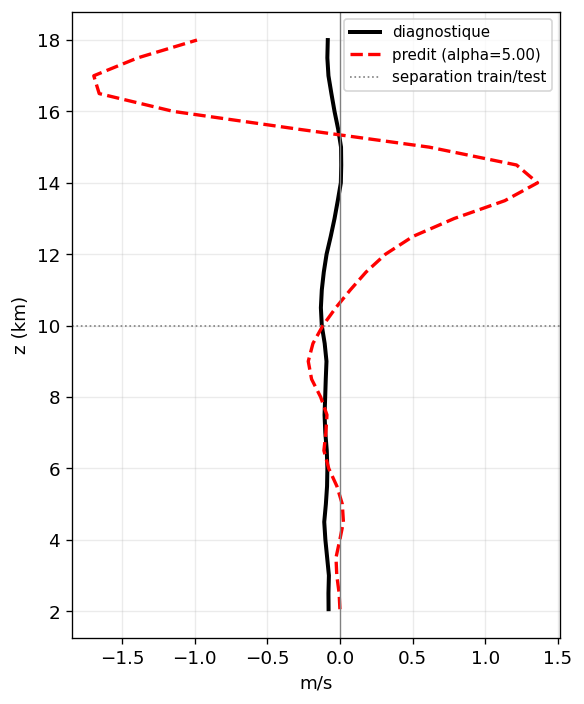

In [33]:
# ============================================================
#  §E (corrige) -- eps(z) = alpha/z (forme canonique), alpha
#  ajuste sur TRAIN, teste sur TEST -- un seul parametre, honnete
# ============================================================
from scipy.optimize import minimize_scalar

def predict_Du(alpha, zb_, ubar_, z0):
    eps = alpha / np.maximum(zb_, 100.0)              # eps(z)=alpha/z, forme canonique
    cum_eps = np.concatenate([[0.0], np.cumsum(0.5*(eps[1:]+eps[:-1])*np.diff(zb_))])
    dubar_dz = np.gradient(ubar_, zb_)
    Du_p = np.zeros_like(zb_)
    for i in range(len(zb_)):
        K_i = np.exp(-(cum_eps[i] - cum_eps[:i+1]))
        Du_p[i] = -np.trapz(K_i * dubar_dz[:i+1], zb_[:i+1])
    return Du_p

# split spatial (bas/haut de colonne), pas temporel : on a un seul profil moyen
mid = nb_e // 2
train, test = slice(0, mid), slice(mid, nb_e)

def cout(alpha):
    Dp = predict_Du(alpha, zb_e, ubar_e, zb_e[0])
    return np.sum((Du_diag[train] - Dp[train])**2)

res = minimize_scalar(cout, bounds=(0.01, 5.0), method='bounded')
alpha_opt = res.x
Du_pred2 = predict_Du(alpha_opt, zb_e, ubar_e, zb_e[0])

nse_train = 1 - np.sum((Du_diag[train]-Du_pred2[train])**2)/np.sum((Du_diag[train]-Du_diag[train].mean())**2)
nse_test  = 1 - np.sum((Du_diag[test] -Du_pred2[test])**2)/np.sum((Du_diag[test] -Du_diag[test].mean())**2)
print(f"alpha ajuste = {alpha_opt:.3f}  (litterature ~0.2)")
print(f"NSE train (bas de colonne)  : {nse_train:+.3f}")
print(f"NSE test  (haut de colonne) : {nse_test:+.3f}   <- le vrai chiffre a rapporter")

fig, ax = plt.subplots(figsize=(5,6))
ax.plot(Du_diag, zb_e/1e3, 'k-', lw=2.4, label='diagnostique')
ax.plot(Du_pred2, zb_e/1e3, 'r--', lw=2, label=f'predit (alpha={alpha_opt:.2f})')
ax.axhline(zb_e[mid]/1e3, color='grey', ls=':', lw=1, label='separation train/test')
ax.axvline(0, color='grey', lw=.8); ax.set_xlabel('m/s'); ax.set_ylabel('z (km)')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()